In [2]:
import aotools
import numpy
import matplotlib.pyplot as plt
from astropy.io import fits
import PIL
from tqdm import tqdm, trange, tqdm_notebook

In [3]:
data = fits.getdata('tabai5mm.fits')
data[:,:,0:2]=0
array_size=128
padding=2
wavelength=833e-3 #(this is the wavelength data was taken at in microns)
diameter=5e-3 #(pupil diameter in m)
psf_size=array_size*padding
j=0+1j
print(data.shape)

(50, 808, 65)


In [6]:
# check how long it takes to do this for first 100 timepoints
z=aotools.zernikeArray(66,array_size)
z=z[1:] #zernikearray creates an array with piston - our data does not have piston in it, so remove this
frames = data.shape[0]*100
#reshape into a 65 x (array_size*array_size) array
zflat=numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))
psfs = numpy.zeros((frames, psf_size, psf_size))
wfs = numpy.zeros((frames, array_size, array_size))
o=0
for n in range(0,50):
    for m in range(0,100):
        
        #print(n,m)
        dat = data[n,m,:]
        #print(dat.shape)
        
        
        

        #convert to radians!
        wf = numpy.dot(dat,zflat)
        wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
        wf*=aotools.circle(array_size/2, array_size)
        wf*=(2*numpy.pi)/wavelength #convert to radians
        wfs[o]=wf
        complex_phase = numpy.exp(j*wf)
        psf_size=array_size*padding
        padded_pupil = numpy.zeros((psf_size, psf_size), dtype=numpy.complex64)
        padded_pupil[:array_size, :array_size] = complex_phase
        
        psf = numpy.abs(aotools.ft2(padded_pupil, delta=diameter/array_size))**2
        psfs[o] = psf

        o=o+1



        
        
        
        
        
        
        

#get the eye data
#calc all psfs


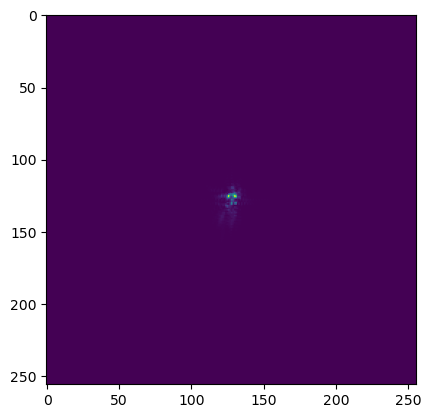

In [7]:
plt.imshow(psfs[0])

In [ ]:
#calculate encircled energy for all aberrations over first 100 timepoints for all ppts.

In [27]:
#import ERICA images for 5 eccentricities
#apply all aberrations to all images
#calculate 3x sharpness metrics for all images with all eccentricities

In [11]:
#plot 5x graphs, on each graph 3 sharpness metrics vs encircled energy, colour by sharpness metric.  Compare.